# Session 3: Context Engineering — Managing Intelligence at Scale

**Data Science Dojo x SambaNova | Deep Agents Webinar Series**

In Session 2 we built a harness from scratch. Today we level up to the **abstraction layer** and master **context engineering** — the art of loading the right information into the context window at the right time.

**What we'll cover:**
1. The **5 context types** every agent manages
2. A **custom context-offloading pattern** built by hand (so you understand the mechanics)
3. The `deepagents` library — the production abstraction
4. **Custom middleware** you write yourself
5. **Pre-built middleware** from the deepagents library
6. **Subagent delegation** — context isolation made easy

Karpathy: "The LLM is the CPU. The context window is RAM. You are the operating system."

## Section 0: Setup

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(os.path.join("..", "..", ".env"), override=True)


True

In [2]:
import sys
sys.path.insert(0, os.path.join(".."))
from utils import format_messages

In [3]:
# LangSmith tracing is automatic when env vars are set
if os.environ.get("LANGSMITH_API_KEY") and os.environ.get("LANGSMITH_TRACING", "").lower() == "true":
    print(f"LangSmith tracing enabled — project: {os.environ.get('LANGSMITH_PROJECT', 'default')}")
else:
    print("LangSmith not configured — tracing disabled.")

LangSmith tracing enabled — project: deep-agents-from-scratch


In [4]:
from langchain_sambanova import ChatSambaNova

MODEL = ChatSambaNova(model="MiniMax-M2.5", temperature=0.0)

# Heavy benchmark task — generates enough content to stress context management
BENCHMARK_TASK = (
    "Research the current global landscape of AI regulation. Cover: "
    "(1) the EU AI Act and its implementation status, "
    "(2) US executive orders and proposed legislation, and "
    "(3) China's AI governance approach. "
    "Save findings to files and produce a structured comparative report."
)
print("Model and benchmark task ready.")

Model and benchmark task ready.


---
## Section 1: The 5 Context Types

Every agent manages 5 types of context. Understanding this taxonomy helps you debug failures and design better agents.

| # | Type | What It Is | When It's Set |
|---|------|-----------|---------------|
| 1 | **Input Context** | System prompts, memory files, skills | Static per run |
| 2 | **Runtime Context** | User metadata, API keys, connections | Per invocation, propagates to subagents |
| 3 | **Compression** | Offloading large outputs, summarizing old messages | Automatic when limits approached |
| 4 | **Isolation** | Subagents quarantine heavy work | Per delegation |
| 5 | **Long-term Memory** | Cross-thread persistence via filesystem or store | Persistent across conversations |

Today we focus on **types 3 and 4** (compression and isolation) — the hardest to get right and the highest-impact.

---
## Section 2: Custom Context Offloading — Build It Once

Before we move to the abstraction, let's build a **single context-offloading tool by hand**. Understanding the mechanics makes the library obvious.

**The pattern:** A search tool that saves full results to a file and returns only a brief summary. The model never sees raw search dumps in its messages.

In [5]:
from typing import Annotated
from datetime import datetime, timezone
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from langchain_community.tools import TavilySearchResults

tavily = TavilySearchResults(max_results=3)

# deepagents stores files as FileData dicts (content + metadata).
# We wrap our content the same way so its built-in read_file/ls/grep can read our files too.
def _file_data(content: str) -> dict:
    now = datetime.now(timezone.utc).isoformat()
    return {"content": content, "encoding": "utf-8", "created_at": now, "modified_at": now}

# Telemetry: capture raw vs offloaded sizes per call
search_telemetry = []


@tool
def search_and_offload(
    query: str,
    filename: str,
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Search the web and OFFLOAD full results to a file. Returns only a short summary."""
    raw = tavily.invoke(query)

    if isinstance(raw, str):
        items = [{"url": "tavily_result", "content": raw}]
    elif isinstance(raw, dict):
        items = raw.get("results", [raw])
    else:
        items = list(raw)

    raw_chars = sum(len(r.get("content", "")) if isinstance(r, dict) else len(str(r)) for r in items)

    full = f"# Search: {query}\n\n"
    urls = []
    for r in items:
        if isinstance(r, dict):
            url, content = r.get("url", "Unknown"), r.get("content", str(r))
        else:
            url, content = "Unknown", str(r)
        urls.append(url)
        full += f"## {url}\n{content}\n\n"

    files = state.get("files", {})
    files[filename] = _file_data(full)  # <-- FileData dict, not raw string

    summary = f"Saved {len(items)} results to '{filename}' ({len(full)} chars). Sources: {urls[:3]}"

    search_telemetry.append({
        "query": query[:50],
        "filename": filename,
        "raw_chars": raw_chars,
        "file_chars": len(full),
        "summary_chars": len(summary),
    })

    return Command(update={
        "files": files,
        "messages": [ToolMessage(summary, tool_call_id=tool_call_id)],
    })

print("Custom search_and_offload tool built (FileData format compatible with deepagents read_file).")

Custom search_and_offload tool built (FileData format compatible with deepagents read_file).


/var/folders/_r/5jlp50wn3ll9_trr9bq_ql7r0000gp/T/ipykernel_64523/1609446968.py:9: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=3)


**That's the core pattern.** A 30-line tool that demonstrates context offloading. Now let's see what a real harness gives us — without writing this each time.

---
## Section 3: Move to the Abstraction — `create_deep_agent()`

The `deepagents` library packages all the patterns we built in Session 2 — and adds production features we couldn't easily build:
- **Automatic compression** at 20K tokens per tool output and at 85% context window
- **Built-in planning tools** (`write_todos`, `read_todos`)
- **Built-in filesystem tools** (`ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`)
- **Subagent delegation** via the `task()` tool
- **Middleware** for intercepting the agent loop
- **Backend swapping** (state, filesystem, store, sandbox)

Let's build a deep agent with our custom search tool plugged in.

In [6]:
from deepagents import create_deep_agent
from langchain_sambanova import ChatSambaNova

# Re-instantiate MODEL here to guarantee class identity matches the freshly-imported BaseChatModel inside deepagents
MODEL = ChatSambaNova(model="MiniMax-M2.5", temperature=0.0)

RESEARCH_PROMPT = """You are a research agent with web search via the search_and_offload tool.

WORKFLOW (no exceptions):
1. Use write_todos to plan
2. For EACH research topic, IMMEDIATELY call search_and_offload(query, filename) - do NOT say you can't search
3. After all searches, use ls then read_file to review your saved findings
4. Use write_file to write the final report
5. Mark todos completed

You CAN search. You MUST use search_and_offload. Do not refuse or add disclaimers about not having search.
"""

# Reset telemetry before run
search_telemetry.clear()

deep_agent = create_deep_agent(
    model=MODEL,
    tools=[search_and_offload],
    system_prompt=RESEARCH_PROMPT,
)

print("Deep agent created with planning, files, and compression for free.")

Deep agent created with planning, files, and compression for free.


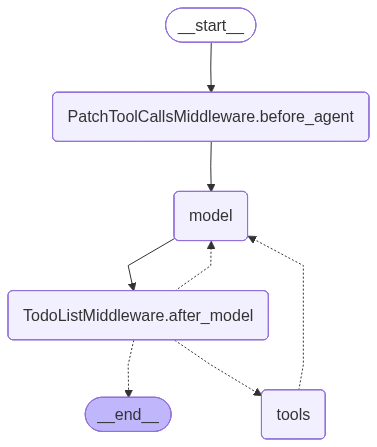

In [7]:
# Visualize the deep agent's graph
from IPython.display import Image, display
display(Image(deep_agent.get_graph().draw_mermaid_png()))

In [8]:
# Run the deep agent on the benchmark task
print("Running deep agent on benchmark task...\n")
result = deep_agent.invoke({"messages": [{"role": "user", "content": BENCHMARK_TASK}]})

print(f"\n=== Results ===")
print(f"Total messages: {len(result['messages'])}")
print(f"Tool calls: {sum(1 for m in result['messages'] if hasattr(m, 'tool_calls') and m.tool_calls)}")
print(f"Todos: {len(result.get('todos', []))}")
print(f"Files: {len(result.get('files', {}))}")

Running deep agent on benchmark task...


=== Results ===
Total messages: 35
Tool calls: 13
Todos: 5
Files: 11


                            search_and_offload telemetry — proof of context offloading                             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Query                                   ┃ Raw Search Chars ┃ Saved to File ┃ In Context (summary) ┃ Compression ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ China AI governance regulations 2024    │            5,228 │         5,518 │                  273 │       20.2x │
│ 2025 generati                           │                  │               │                      │             │
│ US AI executive order 2024 proposed     │            4,091 │         4,563 │                  444 │       10.3x │
│ legislation Co                          │                  │               │                      │             │
│ EU AI Act implementation status 2024    │            4,225 │         4,632 │                  386 │       12.0x │
│ 2025 regulati                           │                  │               │                      │             │
│ China generative AI regulations 2024    │            5,289 │         5,670 │                  326 │       17.4x │
│ interim measu                           │                  │               │                      │             │
│ Biden AI executive order 14110 safe AI  │            4,801 │         5,228 │                  405 │       12.9x │
│ rights safe                             │                  │               │                      │             │
│ EU AI Act full text requirements risk   │            5,286 │         5,700 │                  364 │       15.7x │
│ categories p                            │                  │               │                      │             │
│ US Congress AI legislation 2024 2025    │            4,389 │         4,801 │                  383 │       12.5x │
│ proposed bill                           │                  │               │                      │             │
│ EU AI Act prohibited practices August   │            4,801 │         5,187 │                  354 │       14.7x │
│ 2024 ban hig                            │                  │               │                      │             │
└─────────────────────────────────────────┴──────────────────┴───────────────┴──────────────────────┴─────────────┘


📨 IN-CONTEXT (messages):  9,789 chars (~2,447 tokens)
💾 OFFLOADED (files):       48,000 chars (~12,000 tokens)
📊 % offloaded:             83%


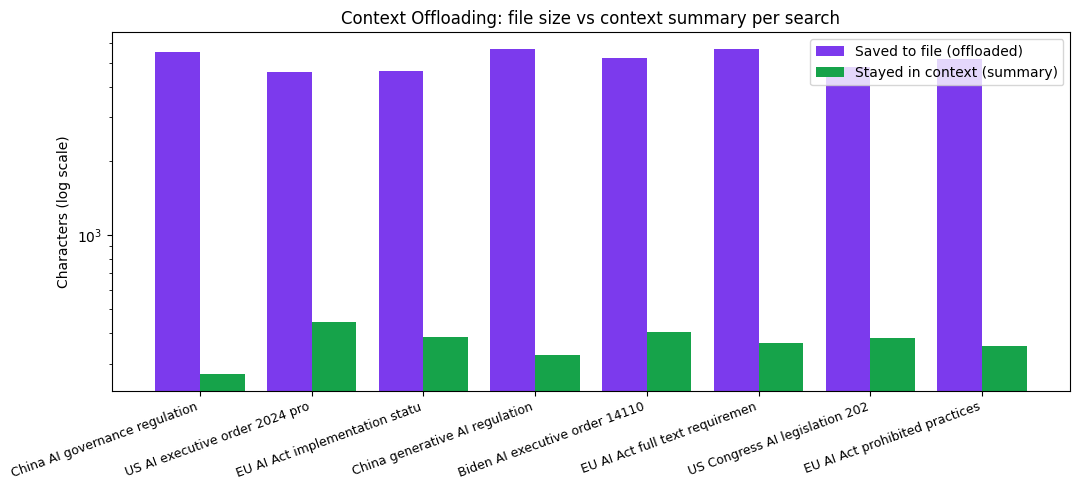


=== PROOF: source content (in file) vs context message (truncated) ===

📁 File 'eu_ai_act_research' (first 400 chars of 4,632 total):
   # Search: EU AI Act implementation status 2024 2025 regulations requirements

## https://addcomply.com/eu-ai-act-compliance-timeline/
| Date | Milestone | What It Means for Organisations |
| August 2024 | The AI Act entered into force | The regulation became EU law, starting the countdown for implementation. |
| February 2025 | Prohibited (unacceptable risk) AI systems banned and AI literacy becam...

💬 Corresponding context message (full 386 chars):
   Saved 3 results to 'eu_ai_act_research' (4632 chars). Sources: ['https://addcomply.com/eu-ai-act-compliance-timeline/', 'https://www.kennedyslaw.com/en/thought-leadership/article/2026/the-eu-ai-act-implementation-timeline-understanding-the-next-deadline-for-compliance/', 'https://www.bakermckenzie.com/en/insight/publications/resources/product-risk-radar-articles/eu-regulation-on-ai']


In [9]:
# === PROOF OF COMPRESSION: per-search metrics ===
from rich.table import Table
from rich.console import Console
console = Console()

table = Table(title="search_and_offload telemetry — proof of context offloading")
table.add_column("Query", style="cyan")
table.add_column("Raw Search Chars", justify="right", style="red")
table.add_column("Saved to File", justify="right", style="yellow")
table.add_column("In Context (summary)", justify="right", style="green")
table.add_column("Compression", justify="right", style="bold magenta")
for s in search_telemetry:
    ratio = s["file_chars"] / s["summary_chars"] if s["summary_chars"] else 0
    table.add_row(s["query"], f"{s['raw_chars']:,}", f"{s['file_chars']:,}", f"{s['summary_chars']}", f"{ratio:.1f}x")
console.print(table)

# === FINAL CONTEXT STATE: messages vs files ===
msg_chars = sum(len(str(m.content)) for m in result["messages"] if hasattr(m, 'content') and m.content)
file_chars = sum(len(c.get('content', '') if isinstance(c, dict) else (c if isinstance(c, str) else str(c))) for c in result.get("files", {}).values())
print(f"\n📨 IN-CONTEXT (messages):  {msg_chars:,} chars (~{msg_chars//4:,} tokens)")
print(f"💾 OFFLOADED (files):       {file_chars:,} chars (~{file_chars//4:,} tokens)")
if (msg_chars + file_chars) > 0:
    print(f"📊 % offloaded:             {file_chars / (msg_chars + file_chars) * 100:.0f}%")

# === BAR CHART: file size vs context summary per search ===
import matplotlib.pyplot as plt
if search_telemetry:
    fig, ax = plt.subplots(figsize=(11, 5))
    queries = [s["query"][:30] for s in search_telemetry]
    file_sizes = [s["file_chars"] for s in search_telemetry]
    ctx_sizes = [s["summary_chars"] for s in search_telemetry]
    x = range(len(queries))
    ax.bar([i-0.2 for i in x], file_sizes, width=0.4, label="Saved to file (offloaded)", color="#7c3aed")
    ax.bar([i+0.2 for i in x], ctx_sizes, width=0.4, label="Stayed in context (summary)", color="#16a34a")
    ax.set_xticks(list(x))
    ax.set_xticklabels(queries, rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Characters (log scale)")
    ax.set_yscale("log")
    ax.set_title("Context Offloading: file size vs context summary per search")
    ax.legend()
    plt.tight_layout()
    plt.show()

# === BEFORE / AFTER: show actual content ===
print("\n=== PROOF: source content (in file) vs context message (truncated) ===")
files = result.get("files", {})
if files:
    first_file = list(files.keys())[0]
    raw = files[first_file]
    content = raw.get('content', '') if isinstance(raw, dict) else str(raw)
    print(f"\n📁 File '{first_file}' (first 400 chars of {len(content):,} total):")
    print(f"   {content[:400]}...")
    for m in result["messages"]:
        if type(m).__name__ == "ToolMessage" and first_file in str(m.content):
            print(f"\n💬 Corresponding context message (full {len(str(m.content))} chars):")
            print(f"   {m.content}")
            break

**Notice:** We wrote almost no code. `create_deep_agent()` gave us a working planning loop, virtual file system, graph structure, and compression hooks. We just plugged in our custom search tool and a system prompt. **This is the value of the abstraction.**

---
## Section 4: Custom Middleware — Build Your Own

**Middleware** wraps the agent loop with pre/post hooks. Use it for logging, validation, dynamic context injection, guardrails — without changing tool or agent code.

Let's write a middleware that:
1. Logs every model call (observability)
2. Tracks token usage and warns at a budget threshold

In [10]:
from langchain.agents.middleware import AgentMiddleware


class ObservabilityMiddleware(AgentMiddleware):
    """Logs every model call, tracks token usage, and counts tool invocations."""

    def __init__(self, token_budget: int = 30000):
        super().__init__()
        self.token_budget = token_budget
        self.timeline = []          # token count at each model call
        self.tool_call_counts = {}  # tool name -> total calls

    def before_model(self, state, runtime):
        """Runs BEFORE every model call. Capture context size."""
        msgs = state.get("messages", [])
        est = sum(len(str(m.content)) // 4 for m in msgs if hasattr(m, "content") and m.content)
        self.timeline.append({
            "call": len(self.timeline) + 1,
            "messages": len(msgs),
            "tokens": est,
            "over_budget": est > self.token_budget,
        })
        return None  # None = continue normally

    def after_model(self, state, runtime):
        """Runs AFTER every model call. Count tool invocations."""
        last = state["messages"][-1]
        for tc in (getattr(last, "tool_calls", None) or []):
            self.tool_call_counts[tc["name"]] = self.tool_call_counts.get(tc["name"], 0) + 1
        return None


obs_middleware = ObservabilityMiddleware(token_budget=30000)
print("Custom ObservabilityMiddleware ready — captures token timeline and tool counts.")

Custom ObservabilityMiddleware ready — captures token timeline and tool counts.


Running deep agent with custom middleware...



Tool Call Breakdown (20 total 
         intercepted)         
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Tool               ┃ Calls ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ search_and_offload │     9 │
│ write_todos        │     3 │
│ read_file          │     3 │
│ write_file         │     3 │
│ ls                 │     1 │
│ glob               │     1 │
└────────────────────┴───────┘


Token-in-context timeline across 13 model calls:



┏━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┓
┃ Call # ┃ Messages ┃ Est Tokens ┃ Status ┃
┡━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━┩
│ 1      │        1 │         67 │ OK ✓   │
│ 2      │        3 │        170 │ OK ✓   │
│ 3      │        7 │        447 │ OK ✓   │
│ 4      │       11 │        497 │ OK ✓   │
│ 5      │       13 │        497 │ OK ✓   │
│ 6      │       15 │        497 │ OK ✓   │
│ 7      │       19 │        766 │ OK ✓   │
│ 8      │       23 │      1,053 │ OK ✓   │
│ 9      │       25 │      1,158 │ OK ✓   │
│ 10     │       27 │      1,166 │ OK ✓   │
│ 11     │       29 │      1,176 │ OK ✓   │
│ 12     │       31 │      1,187 │ OK ✓   │
│ 13     │       33 │      1,292 │ OK ✓   │
└────────┴──────────┴────────────┴────────┘

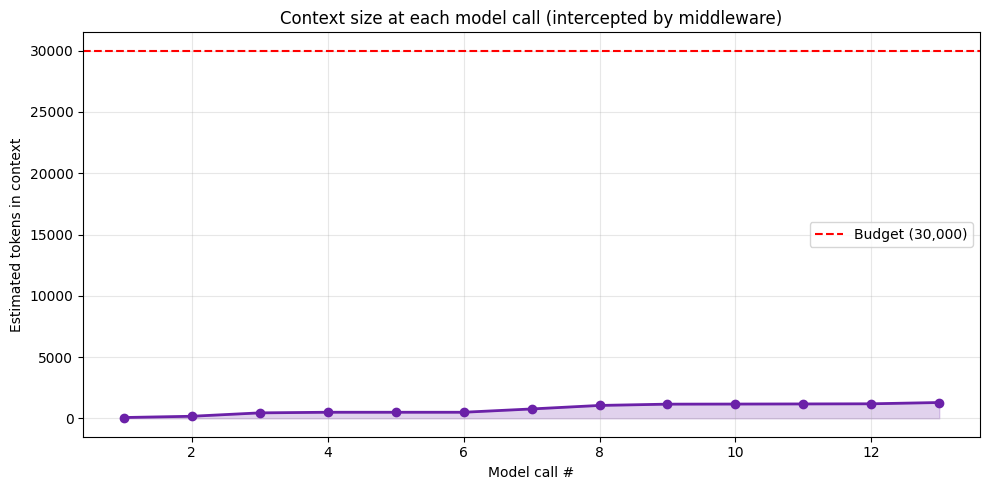


=== Summary ===
  Model calls intercepted: 13
  Files offloaded: 12
  Context grew by: 1,225 tokens (despite 9 searches)


In [11]:
# Reset middleware telemetry for fresh run
obs_middleware.timeline.clear()
obs_middleware.tool_call_counts.clear()
search_telemetry.clear()

deep_agent_with_mw = create_deep_agent(
    model=MODEL,
    tools=[search_and_offload],
    system_prompt=RESEARCH_PROMPT,
    middleware=[obs_middleware],
)

print("Running deep agent with custom middleware...\n")
result_mw = deep_agent_with_mw.invoke({
    "messages": [{"role": "user", "content": BENCHMARK_TASK}]
})

# === MIDDLEWARE TELEMETRY: tool call breakdown ===
from rich.table import Table
from rich.console import Console
console = Console()

tt = Table(title=f"Tool Call Breakdown ({sum(obs_middleware.tool_call_counts.values())} total intercepted)")
tt.add_column("Tool", style="cyan")
tt.add_column("Calls", justify="right", style="green")
for name, cnt in sorted(obs_middleware.tool_call_counts.items(), key=lambda x: -x[1]):
    tt.add_row(name, str(cnt))
console.print(tt)

# === Token-in-context timeline ===
print(f"\nToken-in-context timeline across {len(obs_middleware.timeline)} model calls:\n")
tt2 = Table()
tt2.add_column("Call #", style="bold")
tt2.add_column("Messages", justify="right")
tt2.add_column("Est Tokens", justify="right", style="cyan")
tt2.add_column("Status", style="yellow")
for entry in obs_middleware.timeline:
    status = "OVER BUDGET ⚠" if entry["over_budget"] else "OK ✓"
    tt2.add_row(str(entry["call"]), str(entry["messages"]), f"{entry['tokens']:,}", status)
console.print(tt2)

# === CHART: token growth across calls ===
import matplotlib.pyplot as plt
if obs_middleware.timeline:
    fig, ax = plt.subplots(figsize=(10, 5))
    calls = [e["call"] for e in obs_middleware.timeline]
    tokens = [e["tokens"] for e in obs_middleware.timeline]
    ax.plot(calls, tokens, marker="o", linewidth=2, color="#6b21a8")
    ax.axhline(y=obs_middleware.token_budget, color="red", linestyle="--", label=f"Budget ({obs_middleware.token_budget:,})")
    ax.fill_between(calls, tokens, alpha=0.2, color="#6b21a8")
    ax.set_xlabel("Model call #")
    ax.set_ylabel("Estimated tokens in context")
    ax.set_title("Context size at each model call (intercepted by middleware)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(f"\n=== Summary ===")
print(f"  Model calls intercepted: {len(obs_middleware.timeline)}")
print(f"  Files offloaded: {len(result_mw.get('files', {}))}")
tokens_growth = obs_middleware.timeline[-1]['tokens'] - obs_middleware.timeline[0]['tokens']
print(f"  Context grew by: {tokens_growth:,} tokens (despite {len(search_telemetry)} searches)")

**That's middleware.** Same agent. Same tools. We just wrapped the model loop with hooks. The agent code didn't change.

In production you'd add: cost tracking, PII filtering, loop detection, dynamic prompt injection.

---
## Section 5: Pre-Built Middleware — `SummarizationToolMiddleware`

`deepagents` ships with production middleware ready to plug in. The most useful one for context engineering: **`SummarizationToolMiddleware`** — gives the agent a tool to summarize its own conversation when it decides it's a good moment.

This is on top of the automatic summarization at 85% window. The agent can call it proactively between tasks.

In [12]:
from deepagents.middleware.summarization import create_summarization_tool_middleware
from deepagents.backends import StateBackend

# StateBackend: the default — files live in agent state (ephemeral per-thread)
summarization_mw = create_summarization_tool_middleware(MODEL, StateBackend)

deep_agent_with_summarization = create_deep_agent(
    model=MODEL,
    tools=[search_and_offload],
    system_prompt=RESEARCH_PROMPT + "\n\nIf the conversation is getting long, use the summarize tool between major tasks to compress your history.",
    middleware=[obs_middleware, summarization_mw],
)

print("Deep agent with pre-built SummarizationToolMiddleware + custom ObservabilityMiddleware ready.")
print("This is the power of composition — stack middleware to layer behaviors.")

Deep agent with pre-built SummarizationToolMiddleware + custom ObservabilityMiddleware ready.
This is the power of composition — stack middleware to layer behaviors.


Running deep agent with SummarizationToolMiddleware...



                Custom MW only vs Custom MW + SummarizationToolMiddleware                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric                      ┃ Without Summarization ┃ With SummarizationToolMiddleware ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Final messages in state     │ 34                    │ 29                               │
│ Final context (chars)       │ 10,118                │ 9,442                            │
│ Files                       │ 12                    │ 8                                │
│ Model calls in this run     │ see Section 4         │ 11                               │
│ compact_conversation called │ N/A (no tool)         │ 0                                │
└─────────────────────────────┴───────────────────────┴──────────────────────────────────┘


Note: The model did not need to call compact_conversation on this task — context stayed manageable thanks to our offloading tool.
For tasks that do overflow, the agent decides when to summarize. The pre-built middleware ALSO triggers automatic summarization at 85% of the model's context window.


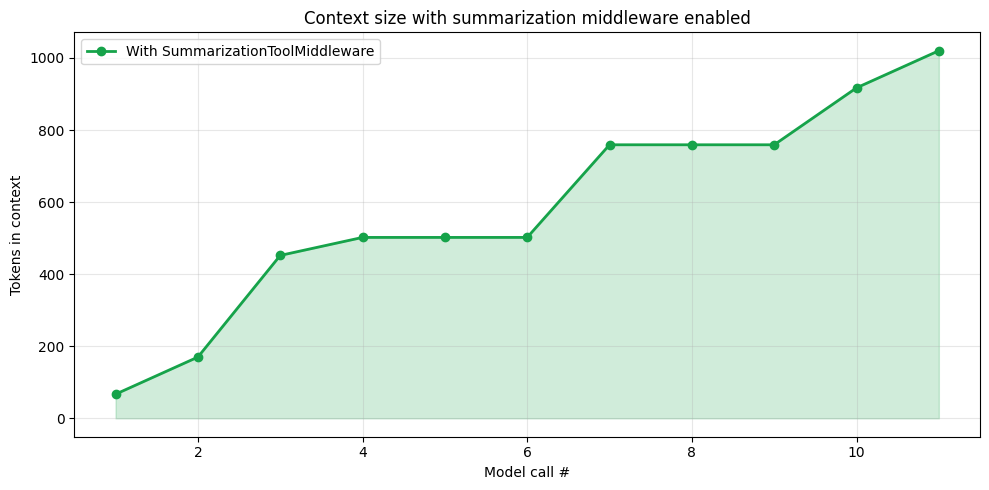

In [13]:
# Reset middleware telemetry
obs_middleware.timeline.clear()
obs_middleware.tool_call_counts.clear()
search_telemetry.clear()

print("Running deep agent with SummarizationToolMiddleware...\n")
result_sum = deep_agent_with_summarization.invoke({
    "messages": [{"role": "user", "content": BENCHMARK_TASK}]
})

# Pull totals: peak tokens + total tokens consumed across all model calls
peak_tokens_with = max(e['tokens'] for e in obs_middleware.timeline) if obs_middleware.timeline else 0
total_tokens_with = sum(e['tokens'] for e in obs_middleware.timeline)
compact_calls = obs_middleware.tool_call_counts.get('compact_conversation', 0)

# Pull the WITHOUT data from result_mw (Section 4)
# We need to re-derive prior token data (we cleared timeline). Use message inspection on result_mw instead.
prior_msg_chars = sum(len(str(m.content)) for m in result_mw['messages'] if hasattr(m, 'content') and m.content)
prior_msg_tokens_estimate = prior_msg_chars // 4

from rich.table import Table
from rich.console import Console
console = Console()
compare = Table(title="Custom MW only vs Custom MW + SummarizationToolMiddleware")
compare.add_column("Metric", style="bold")
compare.add_column("Without Summarization", style="yellow")
compare.add_column("With SummarizationToolMiddleware", style="green")
compare.add_row("Final messages in state", str(len(result_mw['messages'])), str(len(result_sum['messages'])))
compare.add_row("Final context (chars)", f"{prior_msg_chars:,}", f"{sum(len(str(m.content)) for m in result_sum['messages'] if hasattr(m, 'content') and m.content):,}")
compare.add_row("Files", str(len(result_mw.get('files', {}))), str(len(result_sum.get('files', {}))))
compare.add_row("Model calls in this run", "see Section 4", str(len(obs_middleware.timeline)))
compare.add_row("compact_conversation called", "N/A (no tool)", str(compact_calls))
console.print(compare)

if compact_calls == 0:
    print("\nNote: The model did not need to call compact_conversation on this task — context stayed manageable thanks to our offloading tool.\n"
          "For tasks that do overflow, the agent decides when to summarize. The pre-built middleware ALSO triggers automatic summarization at 85% of the model's context window.")

# Token timeline chart for this run
import matplotlib.pyplot as plt
if obs_middleware.timeline:
    fig, ax = plt.subplots(figsize=(10, 5))
    calls = [e['call'] for e in obs_middleware.timeline]
    tokens = [e['tokens'] for e in obs_middleware.timeline]
    ax.plot(calls, tokens, marker='o', linewidth=2, color='#16a34a', label='With SummarizationToolMiddleware')
    ax.fill_between(calls, tokens, alpha=0.2, color='#16a34a')
    ax.set_xlabel('Model call #')
    ax.set_ylabel('Tokens in context')
    ax.set_title('Context size with summarization middleware enabled')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Section 5b: Automatic Compression (deepagents built-in)

Beyond the optional `SummarizationToolMiddleware`, deepagents has **automatic** context compression that needs zero configuration:

- **At 20K tokens per tool output** — the result is auto-saved to a virtual file and replaced in messages with `"Tool result too large, saved at /large_tool_results/..."`
- **At 85% of model context window** — full conversation is summarized, originals preserved on filesystem

Let's prove the 20K auto-offload by giving the agent a tool that deliberately returns a huge response:

In [14]:
@tool
def fetch_huge_doc(topic: str) -> str:
    """Fetch a large document about the topic."""
    # Generates ~129K chars (~32K tokens) — well over the 20K offload threshold
    return f"# Massive document about {topic}\n\n" + (f"Content paragraph about {topic}. " * 3000)

auto_offload_agent = create_deep_agent(
    model=MODEL,
    tools=[fetch_huge_doc],
    system_prompt="You are an assistant. When asked, call fetch_huge_doc(topic) once.",
)

print("Calling agent that will trigger fetch_huge_doc returning ~129K chars...\n")
result_auto = auto_offload_agent.invoke({
    "messages": [{"role": "user", "content": "Fetch the huge doc about quantum computing then tell me what you got back."}]
})

# === Inspect: what did deepagents do automatically? ===
print(f"Files auto-created by deepagents: {list(result_auto.get('files', {}).keys())}\n")

from rich.table import Table
from rich.console import Console
console = Console()
t = Table(title="Automatic 20K-token Tool Output Offloading")
t.add_column("Stage", style="bold")
t.add_column("Size (chars)", justify="right", style="cyan")
t.add_column("Notes", style="yellow")

# Find the original tool output (file) and the replaced ToolMessage
auto_file = None
for fn, content in result_auto.get('files', {}).items():
    if 'large_tool_results' in fn:
        auto_file = (fn, content)
        break

tool_msg = None
for m in result_auto['messages']:
    if type(m).__name__ == 'ToolMessage' and getattr(m, 'name', '') == 'fetch_huge_doc':
        tool_msg = m
        break

if auto_file:
    file_size = len(auto_file[1] if isinstance(auto_file[1], str) else str(auto_file[1]))
    t.add_row("Tool returned (raw)", f"{file_size:,}", "What the tool produced")
    t.add_row("Auto-saved to file", f"{file_size:,}", f"deepagents saved to '{auto_file[0]}'")
if tool_msg:
    msg_size = len(str(tool_msg.content))
    t.add_row("In context (replaced)", f"{msg_size:,}", "Just a pointer to the file")
    if auto_file:
        ratio = len(str(auto_file[1])) / msg_size
        t.add_row("Compression ratio", f"{ratio:.0f}x", "AUTOMATIC, zero config")
console.print(t)

if tool_msg:
    print(f"\n=== What the model saw instead of 129K chars ===")
    print(f"   {str(tool_msg.content)[:500]}")

Calling agent that will trigger fetch_huge_doc returning ~129K chars...

Files auto-created by deepagents: ['/large_tool_results/call_9a6f5e3069954603a1']



                                 Automatic 20K-token Tool Output Offloading                                 
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Stage                 ┃ Size (chars) ┃ Notes                                                             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Tool returned (raw)   │      129,183 │ What the tool produced                                            │
│ Auto-saved to file    │      129,183 │ deepagents saved to '/large_tool_results/call_9a6f5e3069954603a1' │
│ In context (replaced) │        1,703 │ Just a pointer to the file                                        │
│ Compression ratio     │          76x │ AUTOMATIC, zero config                                            │
└───────────────────────┴──────────────┴───────────────────────────────────────────────────────────────────┘


=== What the model saw instead of 129K chars ===
   Tool result too large, the result of this tool call call_9a6f5e3069954603a1 was saved in the filesystem at this path: /large_tool_results/call_9a6f5e3069954603a1

You can read the result from the filesystem by using the read_file tool, but make sure to only read part of the result at a time.

You can do this by specifying an offset and limit in the read_file tool call. For example, to read the first 100 lines, you can use the read_file tool with offset=0 and limit=100.

Here is a preview showing


---
## Section 6: Subagent Delegation — Context Isolation Made Easy

The most powerful context engineering pattern: **delegate noisy work to subagents with isolated contexts**.

In Session 2, we'd have built this manually. With `deepagents`, you just configure subagents as a dict — the library wires up the `task()` tool, isolation, and result aggregation.

In [15]:
# Define a research subagent — plain dict config
research_subagent = {
    "name": "researcher",
    "description": "Conducts focused web research on a single topic. Use this to gather information on one specific question at a time.",
    "system_prompt": (
        "You are a focused research agent. Your job:\n"
        "1. Use search_and_offload to gather information on the assigned topic\n"
        "2. Save findings to a file with a descriptive name\n"
        "3. Return ONLY a 2-3 sentence summary — under 100 words\n"
        "\n"
        "DO NOT include raw search results in your response. The supervisor only needs the headline."
    ),
    "tools": [search_and_offload],
}

SUPERVISOR_PROMPT = """You are a supervisor agent that coordinates research.

Strategy:
1. Use write_todos to plan the research
2. For each major topic, use the task tool to delegate to the 'researcher' subagent
3. The researcher will save findings to files and return only summaries
4. After all delegation, use ls and read_file to review the research files
5. Use write_file to write a final comparative report
6. Mark todos as completed

Your context stays clean — subagents handle the noise.
"""

supervisor_agent = create_deep_agent(
    model=MODEL,
    tools=[search_and_offload],  # Supervisor can also search if needed
    subagents=[research_subagent],  # The library wires up the task() tool
    system_prompt=SUPERVISOR_PROMPT,
)

print("Supervisor + researcher subagent ready.")
print("The library automatically added a task() tool that delegates to 'researcher'.")

Supervisor + researcher subagent ready.
The library automatically added a task() tool that delegates to 'researcher'.


In [ ]:
search_telemetry.clear()

print("Running supervisor agent (will delegate to subagents)...\n")
result_sub = supervisor_agent.invoke({
    "messages": [{"role": "user", "content": BENCHMARK_TASK}]
})

# === SUPERVISOR vs SUBAGENT context isolation visualization ===
from rich.table import Table
from rich.console import Console
console = Console()

supervisor_msg_chars = sum(len(str(m.content)) for m in result_sub['messages'] if hasattr(m, 'content') and m.content)
supervisor_tool_calls = sum(1 for m in result_sub['messages'] if hasattr(m, 'tool_calls') and m.tool_calls)
files = result_sub.get('files', {})
files_chars = sum(len(c.get('content', '') if isinstance(c, dict) else (c if isinstance(c, str) else str(c))) for c in files.values())

isolation_table = Table(title="Context Isolation: Supervisor stays clean while subagents handle noise")
isolation_table.add_column("Metric", style="bold")
isolation_table.add_column("Supervisor", style="green")
isolation_table.add_column("Combined Subagent Files", style="yellow")
isolation_table.add_row("Messages", str(len(result_sub['messages'])), "(isolated, not shown)")
isolation_table.add_row("Total chars", f"{supervisor_msg_chars:,}", f"{files_chars:,}")
isolation_table.add_row("Tool calls", str(supervisor_tool_calls), "(per subagent, not shown)")
console.print(isolation_table)

# Bar chart
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Supervisor messages\n(in context)', 'Subagent files\n(offloaded via state)']
values = [supervisor_msg_chars, files_chars]
colors = ['#16a34a', '#7c3aed']
ax.bar(categories, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Characters')
ax.set_title('Context Isolation: clean supervisor vs offloaded subagent work')
plt.tight_layout()
plt.show()

print(f"\nFiles collected from subagents: {len(files)}")
for fn, content in files.items():
    text = content.get('content', '') if isinstance(content, dict) else (content if isinstance(content, str) else str(content))
    print(f"  {fn}: {len(text):,} chars")

# === Show the actual handoff: supervisor's task() calls and what came back ===
print("\n" + "="*70)
print("SUPERVISOR MESSAGE TRACE — see the task() handoffs to subagents")
print("="*70)
format_messages(result_sub['messages'])

Running supervisor agent (will delegate to subagents)...



**What just happened:**
- Supervisor planned the research (todos)
- Delegated each topic to the `researcher` subagent via the auto-generated `task()` tool
- Each subagent ran in its own **isolated context** (no supervisor history pollution)
- Subagents saved findings to files (shared via state)
- Subagents returned **brief summaries** to the supervisor
- Supervisor synthesized from files with a clean context

This is **Context Isolation** — Type 4 from our taxonomy. With `deepagents`, you describe the pattern; the library handles the wiring.

---
## Section 7: Comparison — Custom vs Library Approaches

Let's tally what we just demonstrated:

| Pattern | Custom (Session 2 style) | deepagents library |
|--------|------------------------|--------------------|
| Planning (todos) | Build write_todos + read_todos manually | Built-in |
| Filesystem | Build ls/read_file/write_file/edit_file manually | Built-in (with grep, glob too) |
| Context offloading | Build search_and_offload manually | Automatic at 20K tokens per tool output |
| Summarization | Build it yourself | Automatic at 85% window + optional `SummarizationToolMiddleware` |
| Middleware | Manually wrap the agent loop | First-class `middleware=[...]` parameter |
| Subagent delegation | Build the task tool, isolation, result aggregation | Just configure a dict |
| Backend swapping | Hard | StateBackend / FilesystemBackend / StoreBackend / Sandbox / Composite |

**The 5 context types in this notebook:**
- Type 1 (Input): `RESEARCH_PROMPT`, `RESEARCHER_PROMPT`, `SUPERVISOR_PROMPT`
- Type 2 (Runtime): LangSmith tracing via env vars
- Type 3 (Compression): `search_and_offload` (manual) + automatic via deepagents
- Type 4 (Isolation): Subagent delegation
- Type 5 (Long-term): Files persist across subagent invocations (StateBackend, single thread)

---
## Exercises

### Exercise 1: Custom Middleware
Write a `CostTrackerMiddleware` that estimates dollars spent per model call (assume $X / 1M input tokens) and prints a warning when cumulative cost exceeds a threshold.

### Exercise 2: Add a Memory File
Use `create_deep_agent(memory=["AGENTS.md"])` with a project conventions file. Observe how it appears in the system prompt automatically.

### Exercise 3: Add Another Subagent
Add a `summarizer` subagent whose only job is to read all research files and produce a final report. Have the supervisor delegate the synthesis step too. Compare the supervisor's final context size to Section 6.

---
## Next Session: May 13 — Skills, Tools & MCP

Sessions 1-3 covered orchestration, harness architecture, and context engineering. Next we connect agents to the outside world:

- **Model Context Protocol (MCP)** — the universal standard for agent-tool communication
- Building custom tools with structured I/O
- Connecting agents to APIs, databases, and external services